In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import itertools
from utils import clean_features, train_val_split

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
FEATURES = ['max_temp_F', 'min_temp_F', 'precipitation_inch', 'snow_inch', 'snow_depth_inch', 'month']
TARGET_LABEL = "min_temp_F"
TRAIN_SAMPLE_STEP_SIZE = 1 # The number of samples between the start of two consecutive windows when creating the training set
USE_MONTH_FEATURE = True
VAL_SIZE = 0.2  # fraction of data to use for validation
T_IMPUTATION_VALUE = 0.0 # Value to use when imputing trace amounts of precipitation
VAL_SAMPLE_STEP_SIZE = 1
TEST_SAMPLE_STEP_SIZE = 14
USE_NORMALIZATION = "all" # False, "features", (normalize all features but not target) "all" (normalize all features including target)
SEQUENCE_LENGTH = 14 # The length of the input sequences
HIDDEN_DIM = 16 # Number of hidden units in the RNN
NUM_LAYERS = 3 # Number of RNN layers
NUM_EPOCHS = 10000
LEARNING_RATE = 0.001
RNN_TYPE = 'LSTM'  # 'GRU' or 'LSTM'

In [4]:
full_train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")
full_train_df.head()

,Date,Maximum Temperature degrees (F),Minimum Temperature degrees (F),Precipitation (inches),Snow (inches),Snow Depth (inches)
0,2010-01-01,6.0,-9.0,T,T,9.00
1,2010-01-02,1.0,-15.0,0.00,0.00,9.00
2,2010-01-03,7.0,-14.0,0.00,0.00,9.00
3,2010-01-04,7.0,-10.0,0.00,0.00,9.00
4,2010-01-05,10.0,-9.0,0.00,0.00,9.00


In [5]:
full_train_df = clean_features(full_train_df, use_month_feature=USE_MONTH_FEATURE, t_imputation_value=T_IMPUTATION_VALUE)
test_df = clean_features(test_df, use_month_feature=USE_MONTH_FEATURE, t_imputation_value=T_IMPUTATION_VALUE)
full_train_df.head()

,date,max_temp_F,min_temp_F,precipitation_inch,snow_inch,snow_depth_inch,month
0,2010-01-01,6.0,-9.0,0.0,0.0,9.0,0.000000
1,2010-01-02,1.0,-15.0,0.0,0.0,9.0,0.032877
2,2010-01-03,7.0,-14.0,0.0,0.0,9.0,0.065753
3,2010-01-04,7.0,-10.0,0.0,0.0,9.0,0.098630
4,2010-01-05,10.0,-9.0,0.0,0.0,9.0,0.131507


In [6]:
extremes = full_train_df[FEATURES].agg(['min', 'max']).to_dict()

def normalize_features(df):
    df_norm = df.copy()
    for feature in FEATURES:
        min_val = extremes[feature]['min']
        max_val = extremes[feature]['max']
        temp_range = max_val - min_val
        if np.isclose(temp_range, 0.0):
            continue
        df_norm[feature] = (df[feature] - min_val) / temp_range
    return df_norm


def denormalize_target(y_norm, extreme):
    min_val = extreme['min']
    max_val = extreme['max']
    y = y_norm * (max_val - min_val) + min_val
    return y

if USE_NORMALIZATION:
    full_train_df = normalize_features(full_train_df)
    test_df = normalize_features(test_df)
full_train_df.head()

,date,max_temp_F,min_temp_F,precipitation_inch,snow_inch,snow_depth_inch,month
0,2010-01-01,0.163793,0.172727,0.0,0.0,0.375,0.000000
1,2010-01-02,0.120690,0.118182,0.0,0.0,0.375,0.002740
2,2010-01-03,0.172414,0.127273,0.0,0.0,0.375,0.005479
3,2010-01-04,0.172414,0.163636,0.0,0.0,0.375,0.008219
4,2010-01-05,0.198276,0.172727,0.0,0.0,0.375,0.010959


In [7]:
train_df, val_df = train_val_split(full_train_df, val_size=VAL_SIZE)

Train set interval: 2010-01-01 to 2022-10-12
Validation set interval: 2022-10-13 to 2025-12-21


In [8]:
class WeatherDataset(Dataset):
    def __init__(self, df, step_size, use_normalization=False, similar_to_test_set=False, group_by_year=False):
        self.X, self.y = self.create_sequences(df, step_size, use_normalization, similar_to_test_set, group_by_year)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

    @staticmethod
    def create_sequences(df, step_size, use_normalization, similar_to_test_set, group_by_year):
        if similar_to_test_set:
            df = df[
                (
                    (df['date'].dt.month > 4) | 
                    ((df['date'].dt.month == 4) & (df['date'].dt.day >= 23))
                ) & 
                (
                    (df['date'].dt.month < 10) | 
                    ((df['date'].dt.month == 10) & (df['date'].dt.day <= 3))
                )
            ]

        X, y = [], []
        if group_by_year:
            for _, group in df.groupby(df['date'].dt.year):
                group_X, group_y = generate_samples_from_data(group, step_size, use_normalization)
                X.extend(group_X)
                y.extend(group_y)
        else:
            X, y = generate_samples_from_data(df, step_size, use_normalization)    
        return torch.stack(X), torch.stack(y)


def generate_samples_from_data(data, step_size, use_normalization):
    X, y = [], []
    for start_idx in range(0, len(data) - SEQUENCE_LENGTH, step_size):
        end_idx = start_idx + SEQUENCE_LENGTH
        features = torch.tensor(data[FEATURES].iloc[start_idx:end_idx].values, dtype=torch.float32)
        target_series = data[TARGET_LABEL].iloc[end_idx]
        if use_normalization == "features":
            target_series = denormalize_target(target_series, extremes[TARGET_LABEL])
        target = torch.tensor(target_series, dtype=torch.float32)
        X.append(features)
        y.append(target)
    return X, y


trainset = WeatherDataset(train_df, step_size=TRAIN_SAMPLE_STEP_SIZE, use_normalization=USE_NORMALIZATION)
valset = WeatherDataset(val_df, step_size=VAL_SAMPLE_STEP_SIZE, use_normalization=USE_NORMALIZATION, similar_to_test_set=True, group_by_year=True)
trainset.X.shape, valset.X.shape

(torch.Size([4654, 14, 6]), torch.Size([450, 14, 6]))

In [9]:
trainset.X[0], trainset.y[0]

(tensor([[0.1638, 0.1727, 0.0000, 0.0000, 0.3750, 0.0000],
         [0.1207, 0.1182, 0.0000, 0.0000, 0.3750, 0.0027],
         [0.1724, 0.1273, 0.0000, 0.0000, 0.3750, 0.0055],
         [0.1724, 0.1636, 0.0000, 0.0000, 0.3750, 0.0082],
         [0.1983, 0.1727, 0.0000, 0.0000, 0.3750, 0.0110],
         [0.2500, 0.2182, 0.0000, 0.0000, 0.3750, 0.0137],
         [0.2500, 0.2909, 0.0145, 0.1350, 0.4583, 0.0164],
         [0.1810, 0.2000, 0.0000, 0.0000, 0.4583, 0.0192],
         [0.1638, 0.1273, 0.0000, 0.0000, 0.4583, 0.0219],
         [0.2414, 0.2000, 0.0000, 0.0000, 0.4583, 0.0247],
         [0.3017, 0.3273, 0.0000, 0.0000, 0.4167, 0.0274],
         [0.3017, 0.2727, 0.0000, 0.0000, 0.4167, 0.0301],
         [0.3534, 0.4273, 0.0000, 0.0000, 0.4167, 0.0329],
         [0.3793, 0.3909, 0.0000, 0.0000, 0.4167, 0.0356]]),
 tensor(0.3636))

In [10]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(ScaledDotProductAttention, self).__init__()
        self.hidden_dim = hidden_dim
        self.scale = hidden_dim ** (1/2)
        self.W_q = nn.Linear(hidden_dim, hidden_dim)
        self.W_k = nn.Linear(hidden_dim, hidden_dim)
        self.W_v = nn.Linear(hidden_dim, hidden_dim)
        
    def forward(self, hidden, encoder_outputs):
        Q = self.W_q(hidden).unsqueeze(1)  # (batch_size, 1, hidden_dim)
        K = self.W_k(encoder_outputs)  # (batch_size, seq_len, hidden_dim)
        V = self.W_v(encoder_outputs)  # (batch_size, seq_len, hidden_dim)
        attention_score = torch.bmm(Q, K.transpose(1, 2)) / self.scale  # (batch_size, 1, seq_len)
        attn_weights = F.softmax(attention_score, dim=2).squeeze(1)  # (batch_size, seq_len)
        context = torch.bmm(attn_weights.unsqueeze(1), V).squeeze(1)  # (batch_size, hidden_dim)
        return context, attn_weights


class RNNWithAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, rnn_type, dropout=0.2):
        super(RNNWithAttention, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.rnn_type = rnn_type

        rnn_types = {'GRU': nn.GRU, 'LSTM': nn.LSTM}
        self.encoder = rnn_types[self.rnn_type](input_dim, hidden_dim, num_layers, batch_first=True)
        self.attention = ScaledDotProductAttention(hidden_dim)
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )
        
    def forward(self, x):
        batch_size = x.size(0)
        encoder_outputs, hidden = self.encoder(x) # (batch_size, seq_len, hidden_dim), (num_layers=1, batch_size, hidden_dim)

        if self.rnn_type == 'GRU':
            encoder_outputs, hidden = self.encoder(x) # (batch_size, seq_len, hidden_dim), (num_layers, batch_size, hidden_dim)
            
        elif self.rnn_type == 'LSTM':
            encoder_outputs, (hidden, cell) = self.encoder(x)
            # encoder_outputs: (batch_size, seq_len, hidden_dim)
            # hidden: (num_layers, batch_size, hidden_dim)
            # cell: (num_layers, batch_size, hidden_dim)

        last_hidden = hidden[-1]  # (batch_size, hidden_dim)
        context, attn_weights = self.attention(last_hidden, encoder_outputs) # (batch_size, hidden_dim), (batch_size, seq_len)
        combined = torch.cat((context, last_hidden), dim=1)
        out = self.decoder(combined)  # (batch_size, output_dim)
        return out, attn_weights


input_dim = trainset.X.shape[2]
output_dim = 1
model = RNNWithAttention(input_dim, HIDDEN_DIM, NUM_LAYERS, output_dim, RNN_TYPE)
model

RNNWithAttention(
  (encoder): LSTM(6, 16, num_layers=3, batch_first=True)
  (attention): ScaledDotProductAttention(
    (W_q): Linear(in_features=16, out_features=16, bias=True)
    (W_k): Linear(in_features=16, out_features=16, bias=True)
    (W_v): Linear(in_features=16, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [11]:
def count_parameters(model):
    total_params = 0
    
    for name, param in model.named_parameters():
        param_count = param.numel()
        total_params += param_count
        
    return total_params

count_parameters(model)

7249

In [12]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False
    
    def check_early_stop(self, mae):
        if self.best_loss is None or mae < self.best_loss:
            self.best_loss = mae
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True

early_stopping = EarlyStopping(patience=250)

In [13]:
def mae(y_pred, y_true):
    mask = y_true != 0
    y_pred, y_true = y_pred[mask], y_true[mask]
    mae = torch.mean(torch.abs((y_pred - y_true) / y_true))
    return mae.item()

def train_model(model, trainset, valset, early_stopping):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    for epoch in range(NUM_EPOCHS):
        model.train()

        optimizer.zero_grad()

        output, attn_weights = model(trainset.X) # The dataset is so small that no batching is needed
        loss = criterion(output.squeeze(), trainset.y)

        loss.backward()
        optimizer.step()

        avg_loss = loss.item() / len(trainset.X)

        model.eval()
        with torch.no_grad():
            y_val_pred = model(valset.X)[0].squeeze()
            val_mae = mae(y_val_pred, valset.y)
            early_stopping.check_early_stop(val_mae)

            if early_stopping.stop_training:
                print(f"Early stopping at epoch {epoch}")
                break
            
            if (epoch + 1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {avg_loss:.8f}')
                print(f'MAE: {val_mae}')
                print()
    
    return model, val_mae


if __name__ == '__main__':
    print("Training GRU with Attention for Time Series Forecasting")
    print("=" * 60)
    model, _ = train_model(model, trainset, valset, early_stopping)

Training GRU with Attention for Time Series Forecasting
Epoch [10/10000], Loss: 0.0001209
MAE: 1.1235647201538086

Epoch [20/10000], Loss: 0.0000939
MAE: 1.0034178495407104

Epoch [30/10000], Loss: 0.0000591
MAE: 0.8012070059776306

Epoch [40/10000], Loss: 0.0000175
MAE: 0.3587955832481384

Epoch [50/10000], Loss: 0.0000184
MAE: 0.10712617635726929

Epoch [60/10000], Loss: 0.0000138
MAE: 0.31722357869148254

Epoch [70/10000], Loss: 0.0000142
MAE: 0.29025620222091675

Epoch [80/10000], Loss: 0.0000129
MAE: 0.20581234991550446

Epoch [90/10000], Loss: 0.0000124
MAE: 0.22793258726596832

Epoch [100/10000], Loss: 0.0000111
MAE: 0.21498197317123413

Epoch [110/10000], Loss: 0.0000099
MAE: 0.1699388325214386

Epoch [120/10000], Loss: 0.0000081
MAE: 0.1367567628622055

Epoch [130/10000], Loss: 0.0000068
MAE: 0.0904950425028801

Epoch [140/10000], Loss: 0.0000067
MAE: 0.07080794870853424

Epoch [150/10000], Loss: 0.0000065
MAE: 0.07169284671545029

Epoch [160/10000], Loss: 0.0000064
MAE: 0.073

In [14]:
def plot_predictions(model, dataset, dataset_name, length):
    model.eval()
    with torch.no_grad():
        y_pred = model(dataset.X)[0].squeeze().detach().numpy()[:length]
        y_true = dataset.y.numpy()[:length]
        plt.plot(y_true, label='True')
        plt.plot(y_pred, label='Predicted')
        plt.legend()
        plt.title(f'Predictions vs True Values on {dataset_name} Set')
        plt.show()

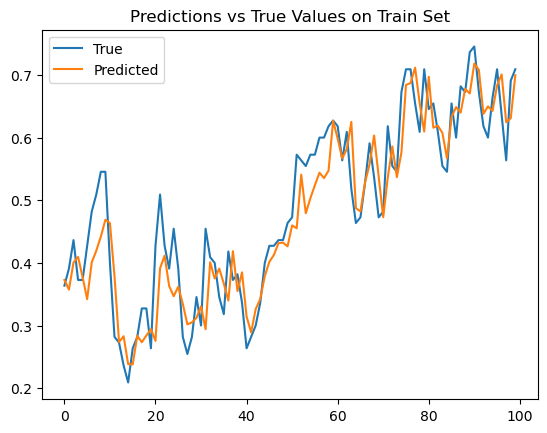

In [15]:
plot_predictions(model, trainset, "Train", length=100)

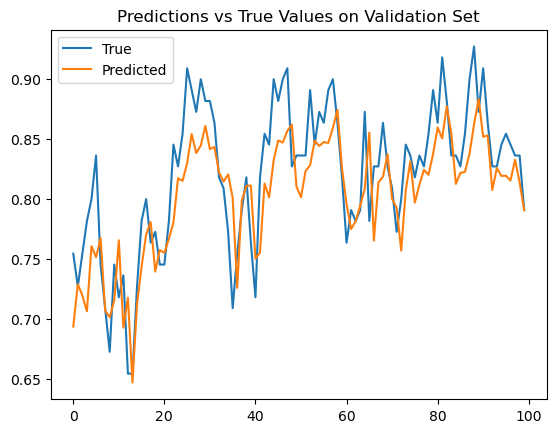

In [16]:
plot_predictions(model, valset, "Validation", length=100)

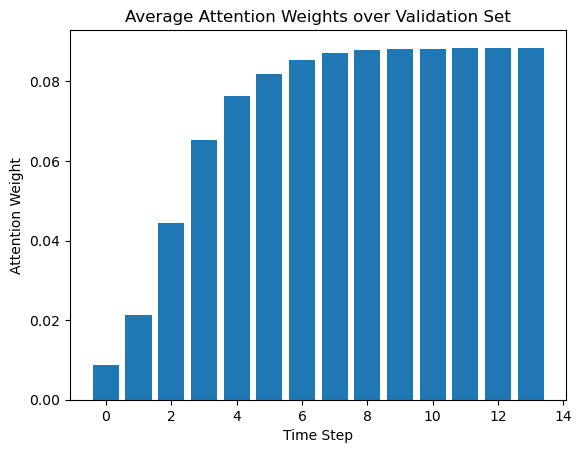

In [17]:
weights = model(valset.X)[1].mean(axis=0).detach().numpy()
plt.bar(range(len(weights)), weights)
plt.title("Average Attention Weights over Validation Set")
plt.xlabel("Time Step")
plt.ylabel("Attention Weight")
plt.show()

In [18]:
def train(use_month_feature, t_imputation_value, use_normalization, train_step_size, hidden_dim, num_layers, model_type):
    full_train_df = pd.read_csv("data/train.csv")
    full_train_df = clean_features(full_train_df)
    if use_normalization:
        full_train_df = normalize_features(full_train_df)
    train_df, val_df = train_val_split(full_train_df, val_size=VAL_SIZE)
    trainset = WeatherDataset(train_df, step_size=train_step_size, use_normalization=use_normalization)
    valset = WeatherDataset(
        val_df,
        step_size=VAL_SAMPLE_STEP_SIZE,
        use_normalization=use_normalization,
        similar_to_test_set=True,
        group_by_year=True,
    )
    model = RNNWithAttention(input_dim, hidden_dim, num_layers, output_dim, model_type)
    n_params = count_parameters(model)
    n_train = len(trainset.X)
    if n_params > 2 * n_train:
        return None, float('inf')  # Model too complex, return infinite loss
    early_stopping = EarlyStopping(patience=200)
    model, val_mae = train_model(model, trainset, valset, early_stopping)
    return model, val_mae


def grid_search():
    param_grid = {
        'use_month_feature': [True, False],
        't_imputation_value': [0.0, 0.001, 0.01, 0.1],
        'use_normalization': [False, "features", "all"],
        'train_step_size': [1, SEQUENCE_LENGTH],
        'hidden_dim': [8, 16, 22, 32, 50],
        'num_layers': [1, 2],
        'model_type': ['GRU', 'LSTM']
    }
    param_combinations = list(itertools.product(*param_grid.values()))
    n_combinations = len(param_combinations)
    print('Total param combinations:', n_combinations)
    best_mae = float('inf')
    best_params = None
    for i in range(n_combinations):  # Number of random trials
        print(f"Trial {i+1}/{n_combinations}")
        use_month_feature, t_imputation_value, use_normalization, train_step_size, hidden_dim, num_layers = param_combinations[i]
        print(f"Params: use_month_feature={use_month_feature}, t_imputation_value={t_imputation_value}, use_normalization={use_normalization}, train_step_size={train_step_size}, hidden_dim={hidden_dim}, num_layers={num_layers}")
        _, val_mae = train(
            use_month_feature,
            t_imputation_value,
            use_normalization,
            train_step_size,
            hidden_dim,
            num_layers
        )
        print(f"MAE: {val_mae}")
        
        if val_mae < best_mae:
            best_mae = val_mae
            best_params = {
                'use_month_feature': use_month_feature,
                't_imputation_value': t_imputation_value,
                'use_normalization': use_normalization,
                'train_step_size': train_step_size,
                'hidden_dim': hidden_dim,
                'num_layers': num_layers
            }
    print()
    print(f"Best MAE: {best_mae} with params: {best_params}")
    
    return best_params, best_mae

# grid_search();

In [19]:
def make_submission(model):
    X = []
    for start_idx in range(0, len(test_df) - TEST_SAMPLE_STEP_SIZE + 1, TEST_SAMPLE_STEP_SIZE):
        end_idx = start_idx + TEST_SAMPLE_STEP_SIZE
        X.append(torch.tensor(test_df[FEATURES].iloc[start_idx:end_idx].values, dtype=torch.float32))
    X = torch.stack(X)
    y_pred = model(X)[0].squeeze().detach().numpy()
    if USE_NORMALIZATION == "all":
        y_pred = denormalize_target(y_pred, extremes[TARGET_LABEL])
    result_df = pd.DataFrame({
        'ID': np.arange(len(y_pred)),
        'Minimum Temperature degrees (F)': y_pred
    })
    result_df.to_csv("submission_deep.csv", index=False)
    return result_df

res = make_submission(model)
res

,ID,Minimum Temperature degrees (F)
0,0,54.874313
1,1,42.506798
2,2,55.758751
3,3,63.106422
4,4,65.402565
5,5,59.562698
6,6,62.102692
7,7,67.434448
8,8,46.165962
9,9,60.816116
